# Customer Churn Analysis for Bank

# This notebook performs data loading, inspection, cleaning, validation, and preparation of the bank customer churn dataset.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("bank_customer_churn_analysis.csv")

In [4]:
df.head()

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn
0,CUST100001,Varun Mishra,29,Male,Delhi,New Delhi,Savings,4,76100,1,...,Active,625,68000,98000,22,19-09-2026,No,Yes,0,0
1,CUST100002,Ashish Menon,44,Male,Assam,Guwahati,Premium,2,86600,3,...,Active,739,20700,418000,16,11-06-2026,Yes,No,1,0
2,CUST100003,Sanjay Sarkar,52,Male,Bihar,Muzaffarpur,Savings,9,45400,1,...,Closed,667,31800,112000,22,11-09-2026,Yes,Yes,1,0
3,CUST100004,Bhavna Shah,25,Female,Rajasthan,Jodhpur,Current,4,51900,1,...,No Loan,696,53500,0,29,06-07-2026,Yes,Yes,1,0
4,CUST100005,Sameer Sharma,57,Male,Maharashtra,Pune,Savings,6,118400,1,...,No Loan,713,25500,0,22,25-02-2026,Yes,Yes,0,1


In [5]:
df.tail()

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn
9995,CUST109996,Kajal Reddy,38,Female,Madhya Pradesh,Jabalpur,Savings,6,11600,2,...,Active,632,33100,162000,23,10-07-2026,Yes,Yes,3,0
9996,CUST109997,Nikhil Iyer,54,Male,Haryana,Ambala,Savings,11,109800,1,...,No Loan,835,41400,0,30,09-08-2026,Yes,Yes,2,1
9997,CUST109998,Nisha Shah,50,Male,Jharkhand,Dhanbad,Savings,2,41600,2,...,No Loan,648,47600,0,23,11-09-2026,Yes,Yes,2,1
9998,CUST109999,Srinivas Mukherjee,59,Male,Delhi,Rohini,Savings,8,28200,1,...,Active,712,32800,402000,19,14-06-2026,No,Yes,2,1
9999,CUST110000,Ishaan Banerjee,40,Male,Karnataka,Mangaluru,Current,9,78800,3,...,No Loan,743,22900,0,16,14-05-2026,Yes,No,0,0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 21


In [7]:
df.columns

Index(['Customer_ID', 'Full_Name', 'Age', 'Gender', 'State', 'City',
       'Account_Type', 'Tenure_Years', 'Account_Balance', 'Num_Products',
       'Has_Credit_Card', 'Loan_Status', 'Credit_Score', 'Monthly_Income',
       'Loan_Amount', 'Transactions_Per_Month', 'Last_Transaction_Date',
       'Mobile_Banking', 'UPI_Usage', 'Complaints', 'Churn'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Customer_ID             10000 non-null  str  
 1   Full_Name               10000 non-null  str  
 2   Age                     10000 non-null  int64
 3   Gender                  10000 non-null  str  
 4   State                   10000 non-null  str  
 5   City                    10000 non-null  str  
 6   Account_Type            10000 non-null  str  
 7   Tenure_Years            10000 non-null  int64
 8   Account_Balance         10000 non-null  int64
 9   Num_Products            10000 non-null  int64
 10  Has_Credit_Card         10000 non-null  str  
 11  Loan_Status             10000 non-null  str  
 12  Credit_Score            10000 non-null  int64
 13  Monthly_Income          10000 non-null  int64
 14  Loan_Amount             10000 non-null  int64
 15  Transactions_Per_Month  10000 n

In [9]:
df.describe()

,Age,Tenure_Years,Account_Balance,Num_Products,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Complaints,Churn
count,10000.00000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.00000
mean,38.16700,6.771700,1.287244e+05,1.731400,710.141600,55846.710000,2.628641e+05,24.009800,0.703100,0.18380
std,10.57558,3.815709,1.304017e+05,0.798572,65.070838,28134.537074,3.841229e+05,4.922106,0.845826,0.38734
min,18.00000,1.000000,3.900000e+03,1.000000,420.000000,15000.000000,0.000000e+00,7.000000,0.000000,0.00000
25%,31.00000,4.000000,5.090000e+04,1.000000,667.000000,36200.000000,0.000000e+00,21.000000,0.000000,0.00000
50%,38.00000,6.000000,9.005000e+04,2.000000,710.500000,49900.000000,1.130000e+05,24.000000,1.000000,0.00000
75%,45.00000,10.000000,1.589000e+05,2.000000,755.000000,68600.000000,4.040000e+05,27.000000,1.000000,0.00000
max,75.00000,15.000000,1.500000e+06,4.000000,850.000000,300000.000000,3.000000e+06,49.000000,6.000000,1.00000


In [10]:
#Check Missing Values
df.isnull().sum()

Customer_ID               0
Full_Name                 0
Age                       0
Gender                    0
State                     0
City                      0
Account_Type              0
Tenure_Years              0
Account_Balance           0
Num_Products              0
Has_Credit_Card           0
Loan_Status               0
Credit_Score              0
Monthly_Income            0
Loan_Amount               0
Transactions_Per_Month    0
Last_Transaction_Date     0
Mobile_Banking            0
UPI_Usage                 0
Complaints                0
Churn                     0
dtype: int64

In [11]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

## Check Unique Values

In [32]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [33]:
df["Account_Type"].unique()

<StringArray>
['Savings', 'Premium', 'Current', 'Salary']
Length: 4, dtype: str

In [34]:
df["Churn"].unique()

array([0, 1])

## Check Frequency of Categorical Values

In [12]:
df["Gender"].value_counts()

Gender
Male      5460
Female    4540
Name: count, dtype: int64

In [36]:
df["Account_Type"].value_counts()

Account_Type
Savings    6172
Salary     1591
Current    1455
Premium     782
Name: count, dtype: int64

In [45]:
df["State"].value_counts()

State
West Bengal       1082
Maharashtra        973
Karnataka          876
Uttar Pradesh      783
Tamil Nadu         762
Delhi              695
Gujarat            667
Telangana          489
Rajasthan          479
Kerala             474
Bihar              359
Punjab             357
Madhya Pradesh     355
Andhra Pradesh     328
Odisha             304
Haryana            262
Jharkhand          254
Assam              193
Chhattisgarh       181
Uttarakhand        127
Name: count, dtype: int64

In [46]:
df["Loan_Status"].value_counts()

Loan_Status
No Loan    4748
Active     3437
Closed     1815
Name: count, dtype: int64

In [37]:
df["Churn"].value_counts()

Churn
0    8162
1    1838
Name: count, dtype: int64

In [38]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    81.62
1    18.38
Name: proportion, dtype: float64

In [26]:
#Check all text columns
text_columns = df.select_dtypes(include="str").columns

print("Text columns:")
print(text_columns.tolist())


Text columns:
['Customer_ID', 'Full_Name', 'Gender', 'State', 'City', 'Account_Type', 'Has_Credit_Card', 'Loan_Status', 'Mobile_Banking', 'UPI_Usage']


In [24]:
#Remove Leading/Trailing Spaces
for col in text_columns:
    df[col] = df[col].str.strip()

In [18]:
#Standardize Text Case
categorical_columns = [
    "Gender",
    "State",
    "City",
    "Account_Type",
    "Has_Credit_Card",
    "Loan_Status",
    "Mobile_Banking",
    "UPI_Usage"
]

for col in categorical_columns:
    df[col] = df[col].str.strip().str.title()

In [22]:
#Convert Date Column
df["Last_Transaction_Date"] = pd.to_datetime(
    df["Last_Transaction_Date"],
    errors="coerce"
)
df["Last_Transaction_Date"].dtype

dtype('<M8[us]')

In [21]:
#Check Invalid Dates
df["Last_Transaction_Date"].isnull().sum()

np.int64(0)

In [27]:
#Check Numerical Columns
numeric_columns = [
    "Age",
    "Tenure_Years",
    "Account_Balance",
    "Num_Products",
    "Credit_Score",
    "Monthly_Income",
    "Loan_Amount",
    "Transactions_Per_Month",
    "Complaints",
    "Churn"
]

df[numeric_columns].dtypes

Age                       int64
Tenure_Years              int64
Account_Balance           int64
Num_Products              int64
Credit_Score              int64
Monthly_Income            int64
Loan_Amount               int64
Transactions_Per_Month    int64
Complaints                int64
Churn                     int64
dtype: object

In [31]:
df["Age"].min(), df["Age"].max()

(np.int64(18), np.int64(75))

In [32]:
#Check Age
df[(df["Age"] < 18) | (df["Age"] > 100)]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [33]:
df["Credit_Score"].min(), df["Credit_Score"].max()

(np.int64(420), np.int64(850))

In [34]:
#Check Credit Score
df[
    (df["Credit_Score"] < 300) |
    (df["Credit_Score"] > 850)
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [48]:
#Check Monthly Income
df[df["Monthly_Income"] <= 0]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [35]:
#Check Account Balance
df[df["Account_Balance"] < 0]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [36]:
#Check Number of Products
df["Num_Products"].unique()

array([1, 3, 2, 4])

In [39]:
#Check Transactions
df[df["Transactions_Per_Month"] < 0]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [38]:
#Check Complaints
df[df["Complaints"] < 0]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


## Check Logical Relationships

In [52]:
df[
    (df["Loan_Status"] == "No Loan") &
    (df["Loan_Amount"] > 0)
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [53]:
df[
    (df["Loan_Status"] == "Active") &
    (df["Loan_Amount"] <= 0)
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [40]:
#Check Credit Card Consistency
df[
    ~df["Has_Credit_Card"].isin(["Yes", "No"])
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [41]:
#Check Mobile Banking
df[
    ~df["Mobile_Banking"].isin(["Yes", "No"])
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [42]:
#Check UPI Usage
df[
    ~df["UPI_Usage"].isin(["Yes", "No"])
]

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,...,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn


In [43]:
#Check Customer ID Format
df["Customer_ID"].head(10)

0    CUST100001
1    CUST100002
2    CUST100003
3    CUST100004
4    CUST100005
5    CUST100006
6    CUST100007
7    CUST100008
8    CUST100009
9    CUST100010
Name: Customer_ID, dtype: str

In [47]:
#Feature Engineering
df["Churn_Status"] = df["Churn"].map({
    0: "Stayed",
    1: "Churned"
})

df["Churn_Status"].value_counts()

Churn_Status
Stayed     8162
Churned    1838
Name: count, dtype: int64

In [48]:
#Create Age Groups
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56+"
    ]
)

df["Age_Group"].value_counts().sort_index()

Age_Group
18-25    1266
26-35    2805
36-45    3451
46-55    1920
56+       558
Name: count, dtype: int64

In [49]:
#Create Credit Score Groups
df["Credit_Score_Group"] = pd.cut(
    df["Credit_Score"],
    bins=[299, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

df["Credit_Score_Group"].value_counts().sort_index()

Credit_Score_Group
Poor          251
Fair         2369
Good         4115
Very Good    2373
Excellent     892
Name: count, dtype: int64

In [50]:
#Create Balance Categories
df["Balance_Category"] = pd.cut(
    df["Account_Balance"],
    bins=[-1, 0, 50000, 100000, 250000, np.inf],
    labels=[
        "No Balance",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["Balance_Category"].value_counts().sort_index()

Balance_Category
No Balance       0
Low           2440
Medium        3041
High          3379
Very High     1140
Name: count, dtype: int64

In [51]:
#Create Income Categories
df["Income_Category"] = pd.qcut(
    df["Monthly_Income"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["Income_Category"].value_counts().sort_index()

Income_Category
Low          2513
Medium       2494
High         2497
Very High    2496
Name: count, dtype: int64

In [52]:
#Create Recency / Inactivity Feature
analysis_date = pd.Timestamp("2026-09-19")

df["Days_Since_Last_Transaction"] = (
    analysis_date - df["Last_Transaction_Date"]
).dt.days

df["Days_Since_Last_Transaction"].describe()

count    10000.000000
mean        53.372700
std         53.353994
min          0.000000
25%         15.000000
50%         37.000000
75%         76.000000
max        365.000000
Name: Days_Since_Last_Transaction, dtype: float64

In [53]:
#Create Activity Categories
df["Activity_Category"] = pd.cut(
    df["Days_Since_Last_Transaction"],
    bins=[-1, 30, 90, 180, np.inf],
    labels=[
        "Active",
        "Recently Inactive",
        "Inactive",
        "Highly Inactive"
    ]
)

df["Activity_Category"].value_counts().sort_index()

Activity_Category
Active               4348
Recently Inactive    3783
Inactive             1533
Highly Inactive       336
Name: count, dtype: int64

In [54]:
print("DATA QUALITY REPORT : ")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["Customer_ID"].duplicated().sum())
print("Missing values:", df.isnull().sum().sum())
print("Churned customers:", df["Churn"].sum())
print("Churn rate:", round(df["Churn"].mean() * 100, 2), "%")


DATA QUALITY REPORT : 
Rows: 10000
Columns: 28
Duplicate rows: 0
Duplicate Customer IDs: 0
Missing values: 0
Churned customers: 1838
Churn rate: 18.38 %


In [80]:
df.to_csv(
    "bank_customer_churn_cleaned.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


## Exploratory Data Analysis (EDA)

In [81]:
# Import libraries for EDA and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Set visualization style
sns.set_style("whitegrid")

In [82]:
# Load cleaned dataset

df = pd.read_csv("bank_customer_churn_cleaned.csv")

# Display first 5 rows
df.head()

,Customer_ID,Full_Name,Age,Gender,State,City,Account_Type,Tenure_Years,Account_Balance,Num_Products,Has_Credit_Card,Loan_Status,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Last_Transaction_Date,Mobile_Banking,UPI_Usage,Complaints,Churn,Churn_Status,Age_Group,Credit_Score_Group,Balance_Category,Income_Category,Days_Since_Last_Transaction,Activity_Category
0,CUST100001,Varun Mishra,29,Male,Delhi,New Delhi,Savings,4,76100,1,Yes,Active,625,68000,98000,22,2026-09-19,No,Yes,0,0,Stayed,26-35,Fair,Medium,High,0,Active
1,CUST100002,Ashish Menon,44,Male,Assam,Guwahati,Premium,2,86600,3,Yes,Active,739,20700,418000,16,2026-06-11,Yes,No,1,0,Stayed,36-45,Good,Medium,Low,100,Inactive
2,CUST100003,Sanjay Sarkar,52,Male,Bihar,Muzaffarpur,Savings,9,45400,1,Yes,Closed,667,31800,112000,22,2026-09-11,Yes,Yes,1,0,Stayed,46-55,Fair,Low,Low,8,Active
3,CUST100004,Bhavna Shah,25,Female,Rajasthan,Jodhpur,Current,4,51900,1,Yes,No Loan,696,53500,0,29,2026-07-06,Yes,Yes,1,0,Stayed,18-25,Good,Medium,High,75,Recently Inactive
4,CUST100005,Sameer Sharma,57,Male,Maharashtra,Pune,Savings,6,118400,1,Yes,No Loan,713,25500,0,22,2026-02-25,Yes,Yes,0,1,Churned,56+,Good,High,Low,206,Highly Inactive


In [83]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 28


In [84]:
# Create a summary table for churn

churn_summary = pd.DataFrame({
    "Customer Status": ["Stayed", "Churned"],
    "Count": [
        (df["Churn"] == 0).sum(),
        (df["Churn"] == 1).sum()
    ],
    "Percentage": [
        round((df["Churn"] == 0).mean() * 100, 2),
        round((df["Churn"] == 1).mean() * 100, 2)
    ]
})

churn_summary

,Customer Status,Count,Percentage
0,Stayed,8162,81.62
1,Churned,1838,18.38


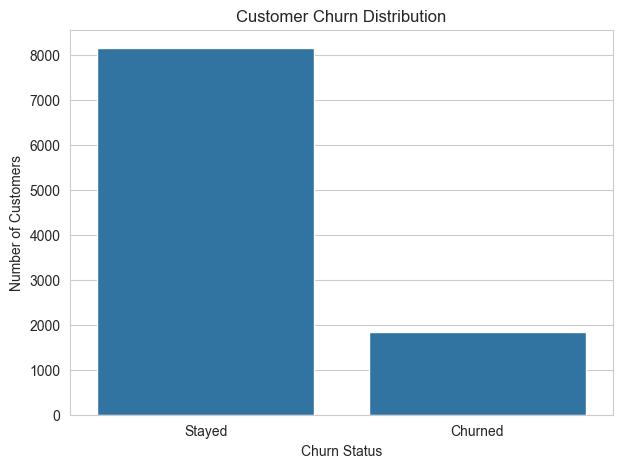

In [85]:
# Visualize churn distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1],
    ["Stayed", "Churned"]
)

plt.show()

In [86]:
# Calculate overall churn rate

churn_rate = df["Churn"].mean() * 100

print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 18.38 %


In [87]:
# Churn count by gender

pd.crosstab(
    df["Gender"],
    df["Churn"]
)

Churn,0,1
Gender,,
Female,3706,834
Male,4456,1004


In [88]:
# Churn percentage by gender

gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn"],
    normalize="index"
) * 100

gender_churn.round(2)

Churn,0,1
Gender,,
Female,81.63,18.37
Male,81.61,18.39


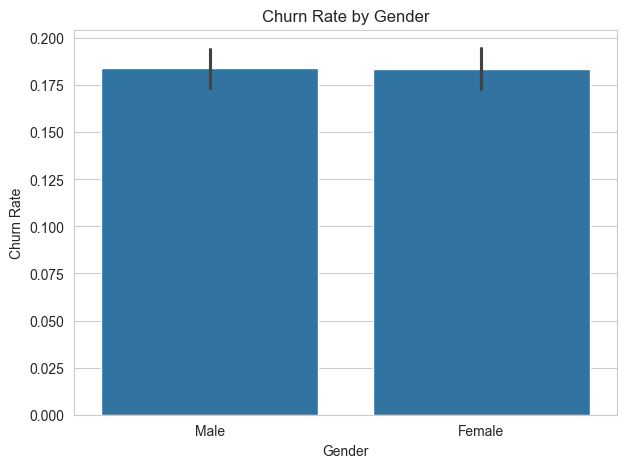

In [102]:
plt.figure(figsize=(7, 5))

# Calculate average churn for each gender
sns.barplot(
    data=df,
    x="Gender",
    y="Churn"
)

# Add title and labels
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")

# Display the chart
plt.show()

In [90]:
# Churn count by age group

pd.crosstab(
    df["Age_Group"],
    df["Churn"]
)

Churn,0,1
Age_Group,,
18-25,1063,203
26-35,2289,516
36-45,2820,631
46-55,1548,372
56+,442,116


In [91]:
# Churn rate by age group

age_churn = pd.crosstab(
    df["Age_Group"],
    df["Churn"],
    normalize="index"
) * 100

age_churn.round(2)

Churn,0,1
Age_Group,,
18-25,83.97,16.03
26-35,81.60,18.40
36-45,81.72,18.28
46-55,80.62,19.38
56+,79.21,20.79


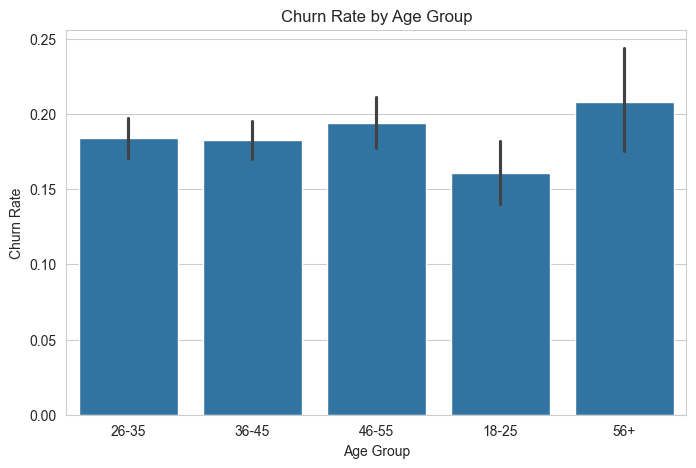

In [92]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Age_Group",
    y="Churn"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate")

plt.show()

In [95]:
# Calculate the churn rate for each state
state_churn = (
    df.groupby("State")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Display the churn rate rounded to 2 decimal places
state_churn.round(2)

State
Haryana           23.66
Madhya Pradesh    21.97
Jharkhand         20.87
Telangana         20.45
Bihar             20.33
West Bengal       19.78
Maharashtra       19.42
Delhi             19.28
Rajasthan         18.37
Karnataka         18.04
Punjab            17.93
Gujarat           17.84
Chhattisgarh      17.13
Uttar Pradesh     16.60
Kerala            16.46
Tamil Nadu        16.14
Assam             16.06
Uttarakhand       15.75
Andhra Pradesh    15.24
Odisha            14.14
Name: Churn, dtype: float64

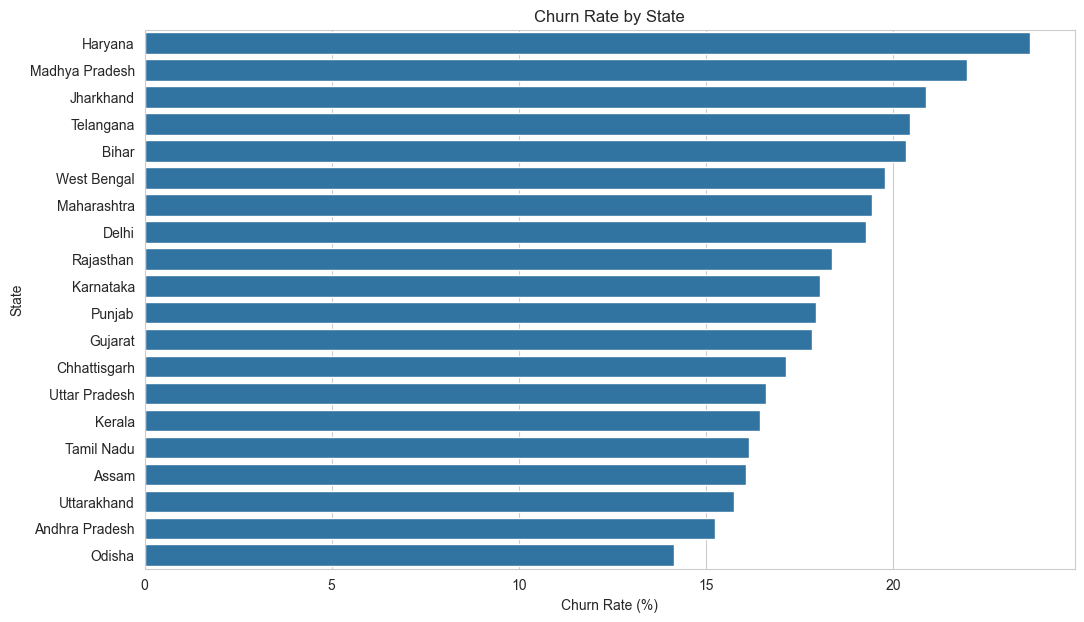

In [96]:
# VISUALIZE CHURN RATE BY STATE

plt.figure(figsize=(12, 7))

# Create a horizontal bar chart
sns.barplot(
    x=state_churn.values,
    y=state_churn.index
)

plt.title("Churn Rate by State")
plt.xlabel("Churn Rate (%)")
plt.ylabel("State")

plt.show()

In [97]:
# Calculate churn rate for each city
city_churn = (
    df.groupby("City")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Display churn rates
city_churn.round(2)

City
Gurugram         26.56
Jabalpur         26.09
Gwalior          25.68
Karimnagar       25.66
Korba            24.39
                 ...  
Visakhapatnam    10.53
Raipur            9.80
Puri              8.75
Guntur            8.43
Dehradun          6.67
Name: Churn, Length: 90, dtype: float64

In [98]:
# GET TOP 10 CITIES BY CHURN RATE

# Select the 10 cities with the highest churn rates
top_10_cities = city_churn.head(10)

# Display the result
top_10_cities.round(2)

City
Gurugram       26.56
Jabalpur       26.09
Gwalior        25.68
Karimnagar     25.66
Korba          24.39
Ambala         24.14
Panipat        23.94
Muzaffarpur    23.46
Bhagalpur      23.08
Asansol        23.03
Name: Churn, dtype: float64

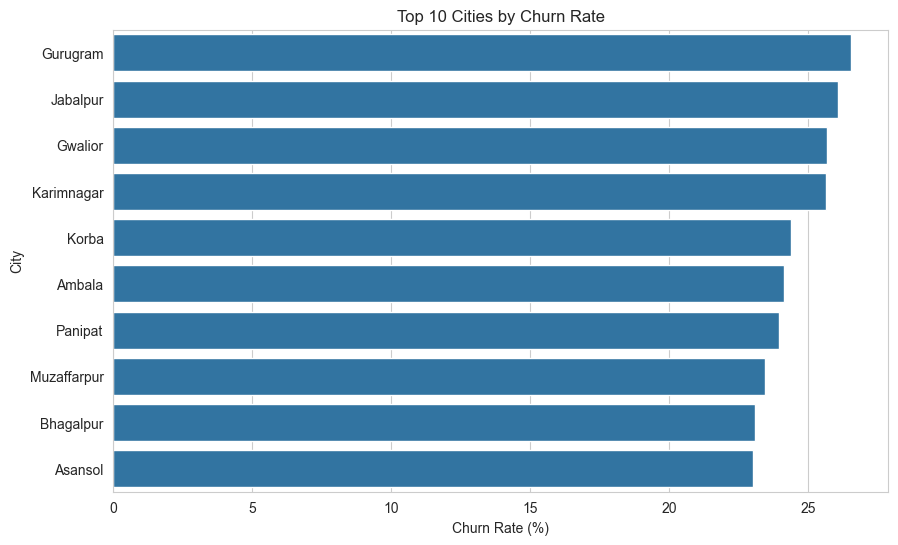

In [99]:
# VISUALIZE TOP 10 CITIES BY CHURN RATE

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_cities.values,
    y=top_10_cities.index
)

plt.title("Top 10 Cities by Churn Rate")
plt.xlabel("Churn Rate (%)")
plt.ylabel("City")

plt.show()

In [100]:
# Calculate churn rate for each account type
account_churn = (
    df.groupby("Account_Type")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

# Display the result
account_churn.round(2)

Account_Type
Premium    19.18
Savings    18.78
Current    17.53
Salary     17.22
Name: Churn, dtype: float64

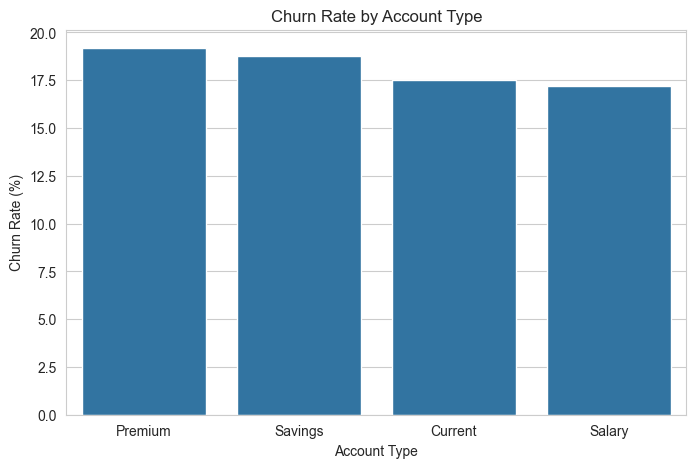

In [101]:
# VISUALIZE CHURN BY ACCOUNT TYPE

plt.figure(figsize=(8, 5))

sns.barplot(
    x=account_churn.index,
    y=account_churn.values
)

plt.title("Churn Rate by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Churn Rate (%)")

plt.show()

In [103]:
# Calculate churn rate for each tenure value
tenure_churn = (
    df.groupby("Tenure_Years")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
tenure_churn.round(2)

Tenure_Years
1     21.28
2     19.32
3     18.38
4     18.27
5     18.40
6     18.53
7     21.24
8     17.82
9     16.67
10    15.72
11    17.90
12    17.36
13    17.45
14    16.91
15    17.73
Name: Churn, dtype: float64

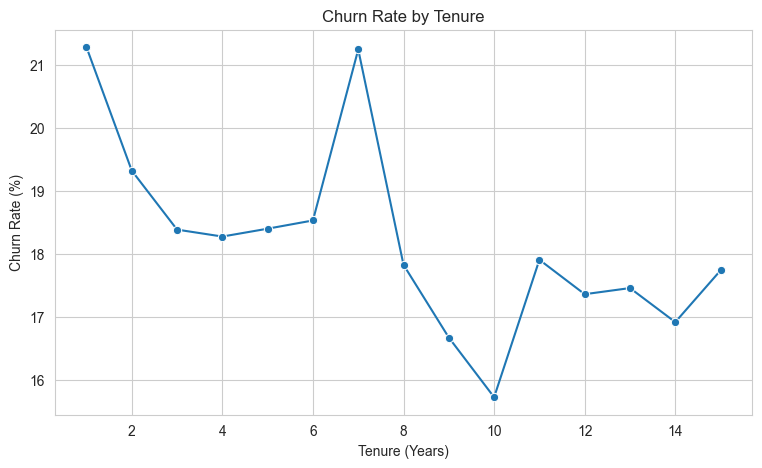

In [104]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    marker="o"
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Years)")
plt.ylabel("Churn Rate (%)")

plt.show()

In [105]:
# Calculate churn rate for each number of banking products
product_churn = (
    df.groupby("Num_Products")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
product_churn.round(2)

Num_Products
1    20.35
2    17.37
3    14.86
4    16.29
Name: Churn, dtype: float64

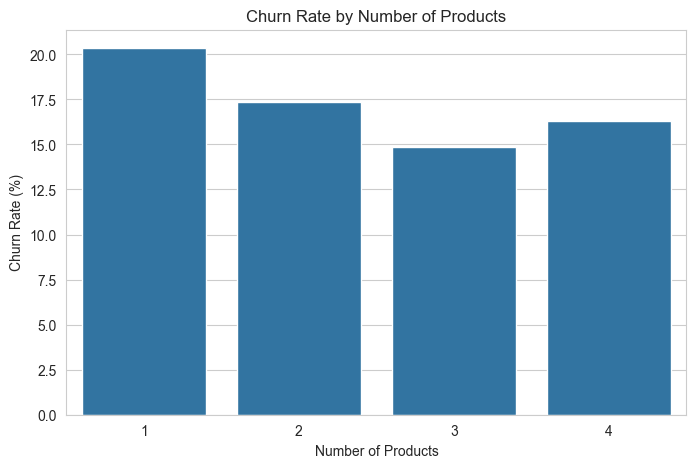

In [106]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=product_churn.index,
    y=product_churn.values
)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")

plt.show()

In [107]:
# Calculate churn rate based on credit card ownership
credit_card_churn = (
    df.groupby("Has_Credit_Card")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
credit_card_churn.round(2)

Has_Credit_Card
No     17.75
Yes    18.63
Name: Churn, dtype: float64

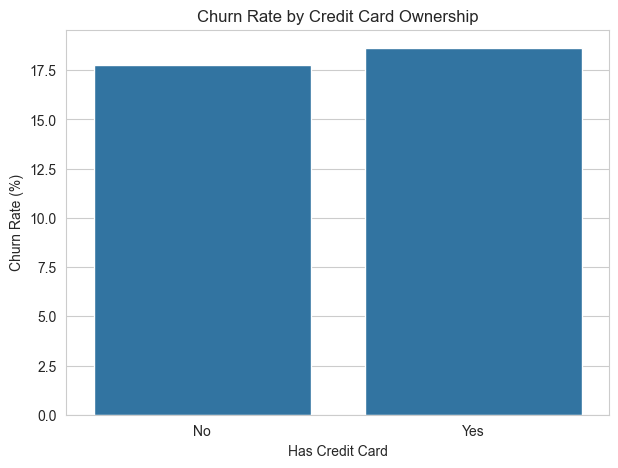

In [108]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=credit_card_churn.index,
    y=credit_card_churn.values
)

plt.title("Churn Rate by Credit Card Ownership")
plt.xlabel("Has Credit Card")
plt.ylabel("Churn Rate (%)")

plt.show()

In [109]:
# Calculate churn rate for each loan status
loan_churn = (
    df.groupby("Loan_Status")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
loan_churn.round(2)

Loan_Status
Active     17.28
Closed     16.03
No Loan    20.07
Name: Churn, dtype: float64

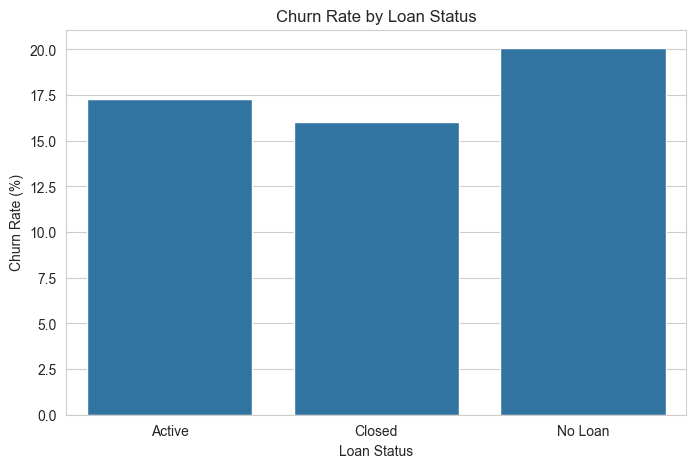

In [110]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=loan_churn.index,
    y=loan_churn.values
)

plt.title("Churn Rate by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Churn Rate (%)")

plt.show()

In [111]:
# Create credit score ranges
df["Credit_Score_Range"] = pd.cut(
    df["Credit_Score"],
    bins=[299, 499, 599, 699, 799, 850],
    labels=[
        "300-499",
        "500-599",
        "600-699",
        "700-799",
        "800-850"
    ]
)

# Calculate churn rate for each credit score range
credit_range_churn = (
    df.groupby("Credit_Score_Range", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
credit_range_churn.round(2)

Credit_Score_Range
300-499     0.00
500-599    20.21
600-699    17.22
700-799    18.79
800-850    20.29
Name: Churn, dtype: float64

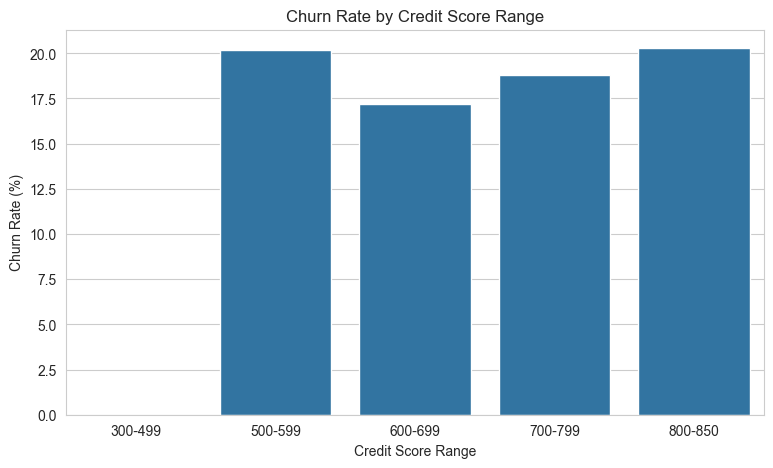

In [112]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=credit_range_churn.index,
    y=credit_range_churn.values
)

plt.title("Churn Rate by Credit Score Range")
plt.xlabel("Credit Score Range")
plt.ylabel("Churn Rate (%)")

plt.show()

In [113]:
# Calculate churn rate for each credit score group
credit_score_churn = (
    df.groupby("Credit_Score_Group", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
credit_score_churn.round(2)

Credit_Score_Group
Excellent    20.29
Fair         17.52
Good         18.30
Poor         18.33
Very Good    18.67
Name: Churn, dtype: float64

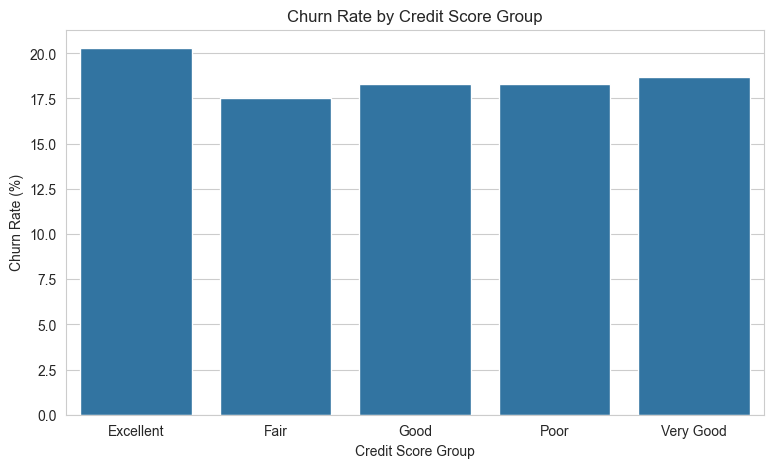

In [114]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=credit_score_churn.index,
    y=credit_score_churn.values
)

plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")

plt.show()

In [115]:
# Create income ranges for analysis
df["Income_Range"] = pd.qcut(
    df["Monthly_Income"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

# Calculate churn rate for each income range
income_range_churn = (
    df.groupby("Income_Range", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
income_range_churn.round(2)

Income_Range
Very Low     19.14
Low          17.37
Medium       17.50
High         19.51
Very High    18.38
Name: Churn, dtype: float64

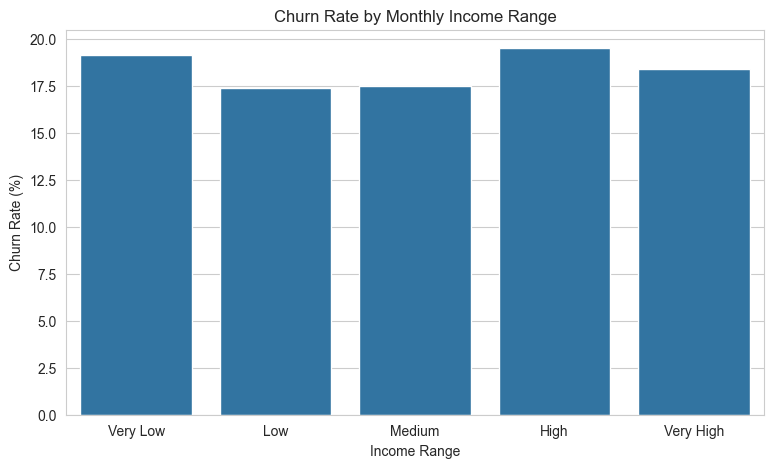

In [116]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=income_range_churn.index,
    y=income_range_churn.values
)

plt.title("Churn Rate by Monthly Income Range")
plt.xlabel("Income Range")
plt.ylabel("Churn Rate (%)")

plt.show()

In [117]:
# Calculate churn rate for each income category
income_churn = (
    df.groupby("Income_Category", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
income_churn.round(2)

Income_Category
High         19.10
Low          18.74
Medium       17.76
Very High    17.91
Name: Churn, dtype: float64

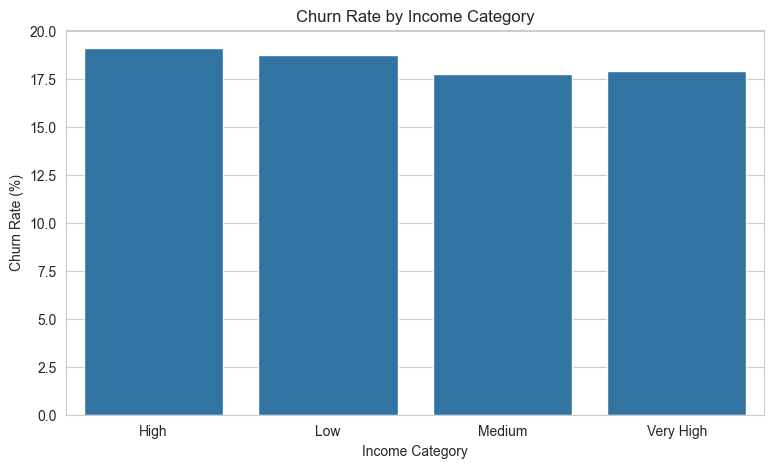

In [118]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=income_churn.index,
    y=income_churn.values
)

plt.title("Churn Rate by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Churn Rate (%)")

plt.show()

In [119]:
# Calculate churn rate for each balance category
balance_churn = (
    df.groupby("Balance_Category", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
balance_churn.round(2)

Balance_Category
High         17.90
Low          18.48
Medium       19.24
Very High    17.28
Name: Churn, dtype: float64

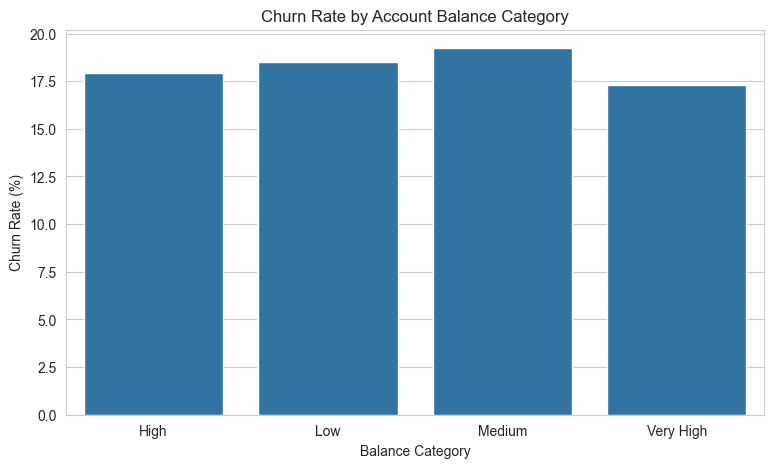

In [120]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=balance_churn.index,
    y=balance_churn.values
)

plt.title("Churn Rate by Account Balance Category")
plt.xlabel("Balance Category")
plt.ylabel("Churn Rate (%)")

plt.show()

In [121]:
# Calculate churn rate for each transaction level
transaction_churn = (
    df.groupby("Transactions_Per_Month")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
transaction_churn.round(2)

Transactions_Per_Month
7     50.00
8     25.00
9      0.00
10    15.79
11    37.93
12    22.22
13    15.94
14    20.18
15    22.56
16    24.30
17    24.56
18    19.14
19    17.95
20    20.79
21    16.22
22    20.08
23    18.85
24    19.29
25    16.43
26    17.81
27    16.60
28    16.58
29    16.96
30    18.16
31    17.79
32    16.20
33    13.91
34    15.31
35    17.57
36    17.50
37    29.41
38    22.22
39    13.33
40    16.67
41     0.00
42     0.00
44     0.00
49     0.00
Name: Churn, dtype: float64

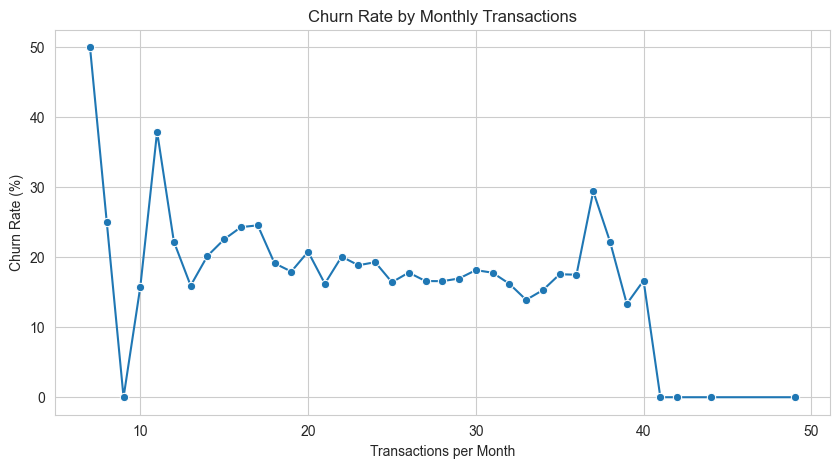

In [122]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=transaction_churn.index,
    y=transaction_churn.values,
    marker="o"
)

plt.title("Churn Rate by Monthly Transactions")
plt.xlabel("Transactions per Month")
plt.ylabel("Churn Rate (%)")

plt.show()

In [123]:
# Calculate churn rate based on mobile banking usage
mobile_churn = (
    df.groupby("Mobile_Banking")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
mobile_churn.round(2)

Mobile_Banking
No     23.22
Yes    16.99
Name: Churn, dtype: float64

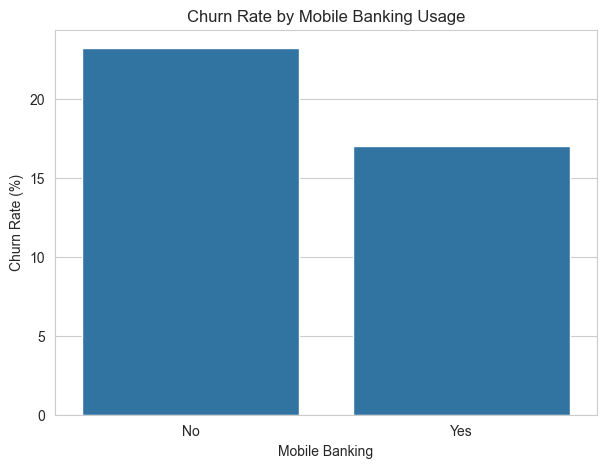

In [124]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=mobile_churn.index,
    y=mobile_churn.values
)

plt.title("Churn Rate by Mobile Banking Usage")
plt.xlabel("Mobile Banking")
plt.ylabel("Churn Rate (%)")

plt.show()

In [125]:
# Calculate churn rate based on UPI usage
upi_churn = (
    df.groupby("UPI_Usage")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
upi_churn.round(2)

UPI_Usage
No     20.92
Yes    17.34
Name: Churn, dtype: float64

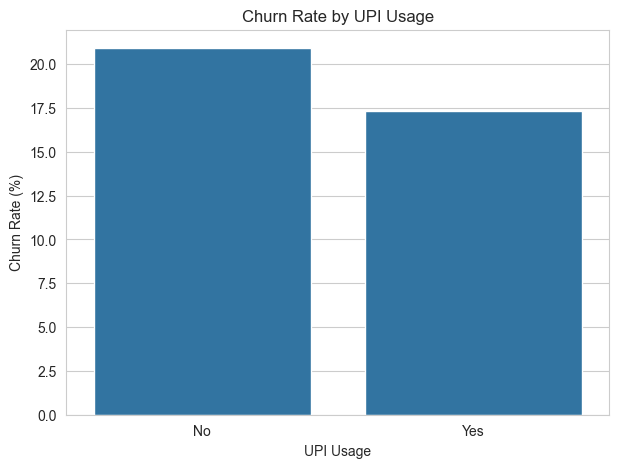

In [126]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=upi_churn.index,
    y=upi_churn.values
)

plt.title("Churn Rate by UPI Usage")
plt.xlabel("UPI Usage")
plt.ylabel("Churn Rate (%)")

plt.show()

In [127]:
# Create ranges for days since the customer's last transaction
df["Transaction_Recency_Group"] = pd.cut(
    df["Days_Since_Last_Transaction"],
    bins=[-1, 30, 60, 90, 180, np.inf],
    labels=[
        "0-30 Days",
        "31-60 Days",
        "61-90 Days",
        "91-180 Days",
        "180+ Days"
    ]
)

# Calculate churn rate for each recency group
recency_churn = (
    df.groupby("Transaction_Recency_Group", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
recency_churn.round(2)

Transaction_Recency_Group
0-30 Days      18.91
31-60 Days     17.40
61-90 Days     18.24
91-180 Days    18.53
180+ Days      18.45
Name: Churn, dtype: float64

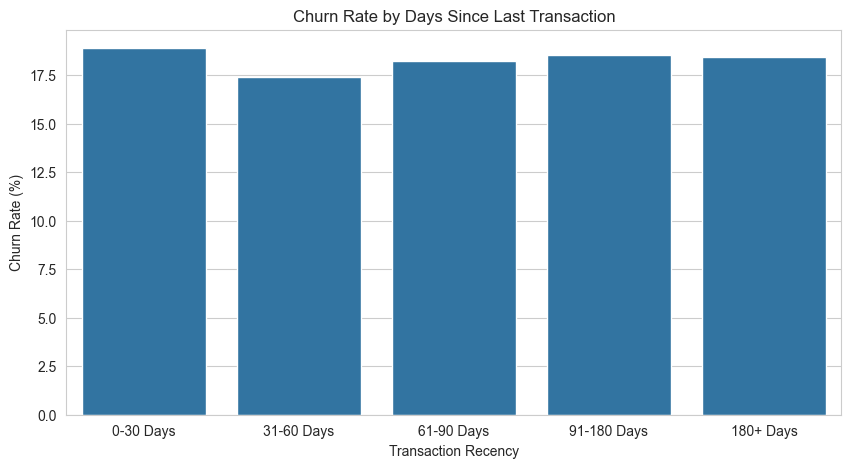

In [128]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=recency_churn.index,
    y=recency_churn.values
)

plt.title("Churn Rate by Days Since Last Transaction")
plt.xlabel("Transaction Recency")
plt.ylabel("Churn Rate (%)")

plt.show()

In [129]:
# Calculate churn rate for each activity category
activity_churn = (
    df.groupby("Activity_Category", observed=True)["Churn"]
    .mean()
    .mul(100)
)

# Display the result
activity_churn.round(2)

Activity_Category
Active               18.91
Highly Inactive      18.45
Inactive             18.53
Recently Inactive    17.71
Name: Churn, dtype: float64

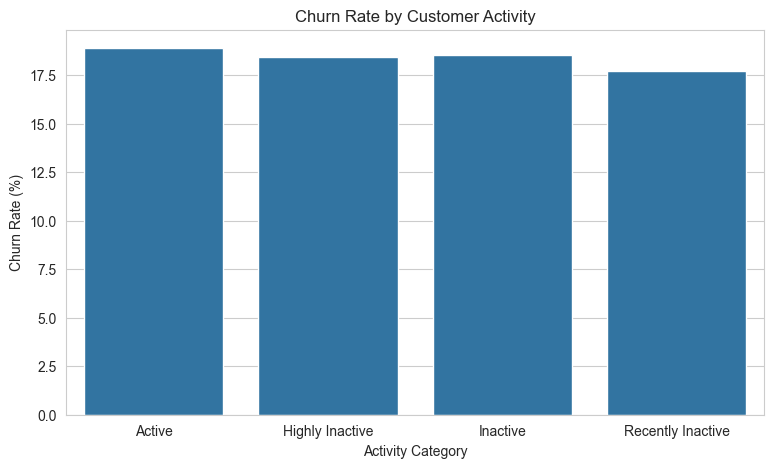

In [130]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=activity_churn.index,
    y=activity_churn.values
)

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Activity Category")
plt.ylabel("Churn Rate (%)")

plt.show()

In [131]:
# Calculate churn rate for each complaint level
complaint_churn = (
    df.groupby("Complaints")["Churn"]
    .mean()
    .mul(100)
)

# Display the result
complaint_churn.round(2)

Complaints
0    16.31
1    18.59
2    22.66
3    27.33
4    56.10
5    30.00
6     0.00
Name: Churn, dtype: float64

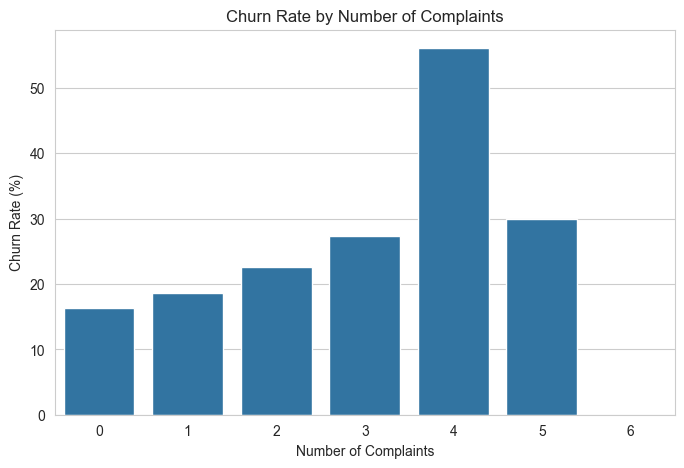

In [132]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=complaint_churn.index,
    y=complaint_churn.values
)

plt.title("Churn Rate by Number of Complaints")
plt.xlabel("Number of Complaints")
plt.ylabel("Churn Rate (%)")

plt.show()

In [133]:
# COMPARE STAYED VS CHURNED CUSTOMERS

# Select important numerical columns
numeric_columns = [
    "Age",
    "Tenure_Years",
    "Account_Balance",
    "Num_Products",
    "Credit_Score",
    "Monthly_Income",
    "Loan_Amount",
    "Transactions_Per_Month",
    "Complaints"
]

# Calculate the average value of each numerical variable
# for stayed and churned customers
churn_comparison = df.groupby("Churn")[numeric_columns].mean()

# Replace 0 and 1 with meaningful labels
churn_comparison.index = ["Stayed", "Churned"]

# Display the comparison
churn_comparison.round(2)

,Age,Tenure_Years,Account_Balance,Num_Products,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Complaints
Stayed,38.05,6.81,129425.79,1.75,709.65,55880.99,269111.37,24.10,0.67
Churned,38.67,6.58,125609.74,1.65,712.34,55694.50,235121.87,23.61,0.84


In [137]:
# CREATE CORRELATION MATRIX

# Select numerical variables for correlation analysis
correlation_columns = [
    "Age",
    "Tenure_Years",
    "Account_Balance",
    "Num_Products",
    "Credit_Score",
    "Monthly_Income",
    "Loan_Amount",
    "Transactions_Per_Month",
    "Complaints",
    "Churn"
]

# Calculate correlations between the selected variables
correlation = df[correlation_columns].corr()

# Display the correlation matrix
correlation.round(2)

,Age,Tenure_Years,Account_Balance,Num_Products,Credit_Score,Monthly_Income,Loan_Amount,Transactions_Per_Month,Complaints,Churn
Age,1.00,-0.01,0.01,-0.01,0.00,-0.01,-0.01,0.01,0.01,0.02
Tenure_Years,-0.01,1.00,0.00,0.01,0.01,0.00,0.00,0.01,0.00,-0.02
Account_Balance,0.01,0.00,1.00,-0.00,-0.00,0.00,-0.00,0.01,-0.00,-0.01
Num_Products,-0.01,0.01,-0.00,1.00,-0.01,-0.00,0.02,0.01,-0.01,-0.05
Credit_Score,0.00,0.01,-0.00,-0.01,1.00,-0.03,0.00,-0.01,0.00,0.02
Monthly_Income,-0.01,0.00,0.00,-0.00,-0.03,1.00,0.00,-0.00,0.01,-0.00
Loan_Amount,-0.01,0.00,-0.00,0.02,0.00,0.00,1.00,0.01,0.01,-0.03
Transactions_Per_Month,0.01,0.01,0.01,0.01,-0.01,-0.00,0.01,1.00,0.02,-0.04
Complaints,0.01,0.00,-0.00,-0.01,0.00,0.01,0.01,0.02,1.00,0.08
Churn,0.02,-0.02,-0.01,-0.05,0.02,-0.00,-0.03,-0.04,0.08,1.00


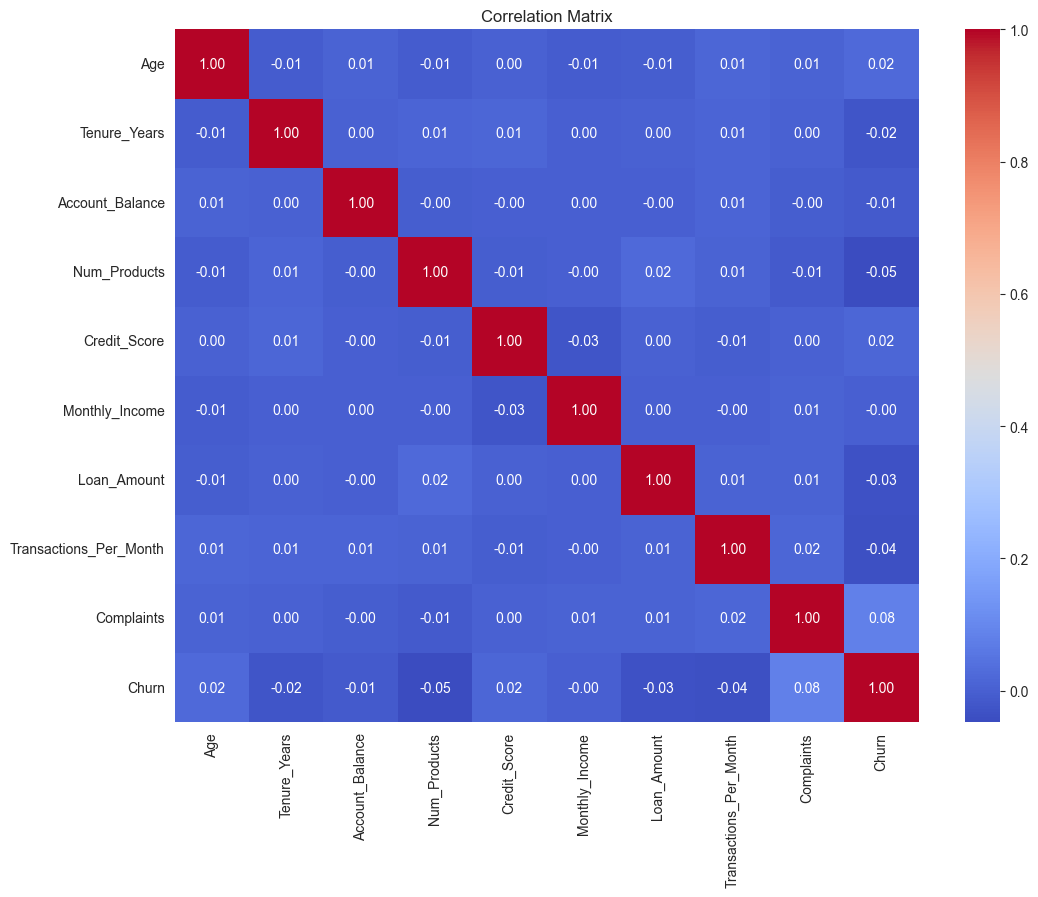

In [138]:
# VISUALIZE CORRELATION MATRIX

# Create the figure
plt.figure(figsize=(12, 9))

# Create a heatmap
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

# Add title
plt.title("Correlation Matrix")

# Display the chart
plt.show()

In [139]:
# FIND VARIABLES MOST ASSOCIATED WITH CHURN

# Select the correlation values related to Churn
churn_correlation = correlation["Churn"].sort_values(
    ascending=False
)

# Display the correlations
churn_correlation.round(2)

Churn                     1.00
Complaints                0.08
Age                       0.02
Credit_Score              0.02
Monthly_Income           -0.00
Account_Balance          -0.01
Tenure_Years             -0.02
Loan_Amount              -0.03
Transactions_Per_Month   -0.04
Num_Products             -0.05
Name: Churn, dtype: float64

In [55]:
# FINAL EDA SUMMARY

print("EDA SUMMARY : ")

# Total number of customers
print("Total Customers:", len(df))

# Number of churned customers
print("Churned Customers:", df["Churn"].sum())

# Number of customers who stayed
print("Customers Stayed:", (df["Churn"] == 0).sum())

# Overall churn rate
print("Overall Churn Rate:", round(df["Churn"].mean() * 100, 2), "%")

# Average age
print("Average Age:", round(df["Age"].mean(), 2))

# Average account balance
print("Average Account Balance:", round(df["Account_Balance"].mean(), 2))

# Average credit score
print("Average Credit Score:", round(df["Credit_Score"].mean(), 2))

# Average monthly income
print("Average Monthly Income:", round(df["Monthly_Income"].mean(), 2))

# Average monthly transactions
print(
    "Average Transactions per Month:",
    round(df["Transactions_Per_Month"].mean(), 2)
)


EDA SUMMARY : 
Total Customers: 10000
Churned Customers: 1838
Customers Stayed: 8162
Overall Churn Rate: 18.38 %
Average Age: 38.17
Average Account Balance: 128724.4
Average Credit Score: 710.14
Average Monthly Income: 55846.71
Average Transactions per Month: 24.01


In [56]:
# REMOVE TEMPORARY EDA COLUMNS

# Remove temporary columns created only for EDA analysis
columns_to_remove = [
    "Credit_Score_Range",
    "Income_Range",
    "Transaction_Recency_Group"
]

df.drop(columns=columns_to_remove, inplace=True, errors="ignore")

# Display the current columns
df.columns

Index(['Customer_ID', 'Full_Name', 'Age', 'Gender', 'State', 'City',
       'Account_Type', 'Tenure_Years', 'Account_Balance', 'Num_Products',
       'Has_Credit_Card', 'Loan_Status', 'Credit_Score', 'Monthly_Income',
       'Loan_Amount', 'Transactions_Per_Month', 'Last_Transaction_Date',
       'Mobile_Banking', 'UPI_Usage', 'Complaints', 'Churn', 'Churn_Status',
       'Age_Group', 'Credit_Score_Group', 'Balance_Category',
       'Income_Category', 'Days_Since_Last_Transaction', 'Activity_Category'],
      dtype='str')

In [57]:
# CHECK FINAL DATASET STRUCTURE

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display all columns
df.columns.tolist()

Number of rows: 10000
Number of columns: 28


['Customer_ID',
 'Full_Name',
 'Age',
 'Gender',
 'State',
 'City',
 'Account_Type',
 'Tenure_Years',
 'Account_Balance',
 'Num_Products',
 'Has_Credit_Card',
 'Loan_Status',
 'Credit_Score',
 'Monthly_Income',
 'Loan_Amount',
 'Transactions_Per_Month',
 'Last_Transaction_Date',
 'Mobile_Banking',
 'UPI_Usage',
 'Complaints',
 'Churn',
 'Churn_Status',
 'Age_Group',
 'Credit_Score_Group',
 'Balance_Category',
 'Income_Category',
 'Days_Since_Last_Transaction',
 'Activity_Category']

In [58]:
# EXPORT FINAL CLEANED DATASET

# Save the final cleaned dataset as a CSV file
df.to_csv("bank_customer_churn_cleaned.csv", index=False)

print("Final cleaned dataset exported successfully.")

Final cleaned dataset exported successfully.
